# Fine-tunning CLIP on a Dataset of Images and Captions of Memes

<pre>
Source:<br>
   https://www.kaggle.com/code/zacchaeus/clip-finetune

Adapted:
    Antonio Esteves @ UMInho, May 2025
</pre>
---

This notebook shows how to fine-tune a pre-trained CLIP model in a custom datset.

Dependencies:<bR>
  ftfy, regex, tqdm, git+https://github.com/openai/CLIP.git

## Import the Necessary Libraries

In [9]:
import os
import glob
import json
import collections
import random
import clip
import torch
import nltk, re, string, collections

from   PIL                     import Image
from   torch                   import nn, optim
import pandas                  as     pd
import numpy                   as     np
from   sklearn.model_selection import train_test_split
from   torch.utils.data        import Dataset, DataLoader, BatchSampler
from   tqdm.notebook           import tqdm
from   matplotlib.pyplot       import imshow
from   nltk.util               import ngrams

%matplotlib inline

In [10]:
BATCH_SIZE = 128
EPOCHS     = 10
IMG_ROOT   = "/AreaGeral/esteves/datasets/meme-project-raw"
JSON_ROOT  = "/AreaGeral/esteves/datasets/meme-project-clean-json"
img_paths  = glob.glob(os.path.join(IMG_ROOT, "*.jpg"))

device     = "cuda:1" if torch.cuda.is_available() else "cpu"

print(f"Torch version: {torch.__version__}")
print(torch.cuda.get_device_name(device))

Torch version: 2.6.0+cu124
NVIDIA TITAN Xp


## Preparing the Model and Data

For each image, the dataset contains multiple captions. For example, the first 5 images have 113, 146, 3, 87, and 132 captions.

In [11]:
# Create a dictionary 'd' where the key is an image path and 
# the values are a list of all captions for that file.

d    = {}
size = 0
for i, img_path in enumerate(img_paths):
    name = img_path.split("/")[-1].split(".")[0]

    with open(os.path.join(JSON_ROOT, name+".json"), "r") as f:
        captions = json.load(f)
        temp     = []
        for cap in captions:
            if "http" not in (cap[0]+ ' '+cap[1]) and len(cap[0]+ ' '+cap[1]) >= 8 and len(cap[0]+ ' '+cap[1]) <= 72:
                temp.append(cap[0]+ ' '+cap[1])
        d[img_path] = temp

        size += len(temp)
        if i<5:
            print(f'[INFO] image {i+1} has {str(len(temp)).zfill(3)} captions and path is {img_path}')

print(f'[INFO] Number of images in the dataset is {len(d)}')
print(f'[INFO] Number of (image, caption) pairs in the dataset is {size}')

[INFO] image 1 has 113 captions and path is /AreaGeral/esteves/datasets/meme-project-raw/i-dont-usually.jpg
[INFO] image 2 has 146 captions and path is /AreaGeral/esteves/datasets/meme-project-raw/hipster-leah.jpg
[INFO] image 3 has 003 captions and path is /AreaGeral/esteves/datasets/meme-project-raw/radiophysics.jpg
[INFO] image 4 has 087 captions and path is /AreaGeral/esteves/datasets/meme-project-raw/meme-tierno.jpg
[INFO] image 5 has 132 captions and path is /AreaGeral/esteves/datasets/meme-project-raw/oh-naruto.jpg
[INFO] Number of images in the dataset is 3000
[INFO] Number of (image, caption) pairs in the dataset is 298737


## Split the Dataset in Training and Test Sets

In [12]:
# Split the dataset of pairs (file,file_captions_list) in 80% for training (d_train) 
# and 20% for test (d_test).
#
# d_train: training dictionary where each key is an image path and the values are 
#          a list of all captions for that file.
# d_test:  test dictionary where each key is an image path and the values are 
#          a list of all captions for that file.

train_img_paths, test_img_paths = train_test_split(
    img_paths,
    test_size    = 0.2,
    random_state = 42,
)

d_train = {k: d[k] for k in train_img_paths}
d_test  = {k: d[k] for k in test_img_paths}

print(f'[INFO] Train set has {str(len(d_train)).zfill(4)} images')
print(f'[INFO] Test  set has {str(len(d_test)).zfill(4)} images')

# First five training files:
#   /AreaGeral/esteves/datasets/meme-project-raw/vader-advice.jpg
#   /AreaGeral/esteves/datasets/meme-project-raw/defendpoppunk.jpg
#   /AreaGeral/esteves/datasets/meme-project-raw/fuming-tourettes-guy.jpg
#   /AreaGeral/esteves/datasets/meme-project-raw/woll-smoth.jpg
#   /AreaGeral/esteves/datasets/meme-project-raw/lol-face.jpg


[INFO] Train set has 2400 images
[INFO] Test  set has 0600 images


## Loading a Pre-trained CLIP Model and Preprocessor

In [13]:
# Load pre-trained the CLIP model version Vit-B/32 
model, preprocess = clip.load("ViT-B/32", device=device, jit=False)

# Check the images and captions shapes

file_path = os.path.join(IMG_ROOT, "-okay-.jpg")
image = preprocess(
    Image.open(file_path)
).unsqueeze(0).to(device)

text = clip.tokenize(["a diagram", "a dog", "a cat"]).to(device)

print(f'[INFO] CLIP model preprocess transformations:\n{preprocess}') 
print(f'[INFO] Image shape: ({image.shape[1]},{image.shape[2]},{image.shape[3]})')
print(f'[INFO] Three tokenized captions shape: {text.shape}')

[INFO] CLIP model preprocess transformations:
Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    <function _convert_image_to_rgb at 0x7f19b81c3060>
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)
[INFO] Image shape: (3,224,224)
[INFO] Three tokenized captions shape: torch.Size([3, 77])


## MemeDataset

In [14]:
class MemeDataset(Dataset):
    '''
    The dataset will contain pairs (image,caption).
    Since for each image there are multipme caption, the size of 
    the dataset is the sum of all caption for each image.
    '''
    def __init__(self, data, preprocess):
        '''
        data:       Dictionary where the key is an image path and the values 
                    are a list of all captions for that file.
        preprocess: Transformations to apply to the image.
        '''
        self.preprocess = preprocess
        self.img_paths  = [] # List of all image paths in the pairs (image_path, caption)
        self.captions   = [] # List of all captions in the pairs (image_path, caption)
        for img_path, captions in data.items():
            for cap in captions:
                self.img_paths.append(img_path)
                self.captions.append(cap)
        self.processed_cache = {}

        for img_path in data:
            self.processed_cache[img_path] = self.preprocess(Image.open(img_path))

        # List with the path for each distinct image in the dataset
        self.img_paths_set = list(data.keys())

        # Dictionary of pairs (file_path: unique_index_file) in the dataset
        self.path2label    = {path: self.img_paths_set.index(path) for path in self.img_paths_set}

    def __len__(self):
        return len(self.captions)

    def __getitem__(self, idx):
        '''
        Returns a triplet (image, caption, index of the image in the list of distint images).
        '''
        img_path = self.img_paths[idx]
        image    = self.processed_cache[img_path]
        caption  = self.captions[idx]
        label    = self.path2label[img_path]
        return image, caption, label

In [15]:
# Create the training and test datasets

train_dataset = MemeDataset(d_train, preprocess)
test_dataset  = MemeDataset(d_test, preprocess)

print(f'[INFO] Train set length is {len(train_dataset)}')
print(f'[INFO] Test  set length is {len(test_dataset)}')
(img0, cap0, id0) = train_dataset[0]
print(f'[INFO] Training set sample 0:\n\tcaption:     {cap0}\n\timage index: {id0}\n\timage:\n\t{img0}')

[INFO] Train set length is 239836
[INFO] Test  set length is 58901
[INFO] Training set sample 0:
	caption:     not sure if vader or luke's father...
	image index: 0
	image:
	tensor([[[-0.8434, -0.8142, -0.8288,  ..., -1.4711, -1.4711, -1.4711],
         [-0.8288, -0.7850, -0.8142,  ..., -1.4565, -1.4565, -1.4565],
         [-0.8288, -0.8142, -0.8434,  ..., -1.4711, -1.4711, -1.4711],
         ...,
         [-0.8288, -0.8142, -0.8434,  ..., -1.4711, -1.4711, -1.4711],
         [-0.8142, -0.7996, -0.8288,  ..., -1.4711, -1.4711, -1.4711],
         [-0.8288, -0.8142, -0.8434,  ..., -1.4711, -1.4711, -1.4711]],

        [[-0.7916, -0.7616, -0.7766,  ..., -1.4219, -1.4219, -1.4219],
         [-0.7766, -0.7316, -0.7616,  ..., -1.4069, -1.4069, -1.4069],
         [-0.7766, -0.7616, -0.7916,  ..., -1.4219, -1.4219, -1.4219],
         ...,
         [-0.7766, -0.7616, -0.7916,  ..., -1.4219, -1.4219, -1.4219],
         [-0.7616, -0.7466, -0.7766,  ..., -1.4219, -1.4219, -1.4219],
         [-0.77

In [16]:
# Print the paths of the first 20 images in the training set.
# train_dataset.path2label -> dictionary of pairs (file_path: unique_file_index).
i = 0
for k,v in train_dataset.path2label.items():
    print(f'[{v}] {k}') # key=file_path, value=file_index
    i += 1
    if i == 20:
        break

[0] /AreaGeral/esteves/datasets/meme-project-raw/vader-advice.jpg
[1] /AreaGeral/esteves/datasets/meme-project-raw/defendpoppunk.jpg
[2] /AreaGeral/esteves/datasets/meme-project-raw/fuming-tourettes-guy.jpg
[3] /AreaGeral/esteves/datasets/meme-project-raw/woll-smoth.jpg
[4] /AreaGeral/esteves/datasets/meme-project-raw/lol-face.jpg
[5] /AreaGeral/esteves/datasets/meme-project-raw/mcdonalds-peeves.jpg
[6] /AreaGeral/esteves/datasets/meme-project-raw/pee-wee-herman.jpg
[7] /AreaGeral/esteves/datasets/meme-project-raw/kiko-.jpg
[8] /AreaGeral/esteves/datasets/meme-project-raw/yaazz.jpg
[9] /AreaGeral/esteves/datasets/meme-project-raw/botota.jpg
[10] /AreaGeral/esteves/datasets/meme-project-raw/holden-caulfield.jpg
[11] /AreaGeral/esteves/datasets/meme-project-raw/fry-squint.jpg
[12] /AreaGeral/esteves/datasets/meme-project-raw/smithies.jpg
[13] /AreaGeral/esteves/datasets/meme-project-raw/high-expectations-asian-father.jpg
[14] /AreaGeral/esteves/datasets/meme-project-raw/balotelli.jpg
[15

## Balanced Batch Sampler

Create a balanced batch sampler that ensures that are no repeated classes in a batch.

In [17]:
# https://github.com/pytorch/pytorch/blob/e5742494f6080c8e6f43c37689fc18a7c4b39dfd/torch/utils/data/dataloader.py#L145
class BalancedBatchSampler(BatchSampler):
    """
    Create a sampler that draws batches of indices relative to dataset triplets,
    where a triplet is composed of (image, caption, index of the image), which
    avoids repeating the same image in each 'n_classes' drawn samples.
    The batch size is 'n_classes * n_samples'. If 'n_samples=1', each batch 
    does not include triplets with the same image. 

    BatchSampler in a MNIST-like dataset sampler, that samples 'n_classes' 
    and within these samples there are no repeated image classes.

    Returns batches of size 'n_classes * n_samples'.
    """
    def __init__(self, labels, n_classes, n_samples):

        # List of file indices for all (image,caption,file index) in the dataset
        self.labels           = labels

        # List of distinct file indices in the dataset
        self.labels_set       = list(set(self.labels.numpy()))

        # Dictionary where each entrey key is a unique image index and the value is 
        # a list of indices of all dataset triplets that use this same image index
        self.label_to_indices = {label: np.where(self.labels.numpy() == label)[0]
                                 for label in self.labels_set}

        for l in self.labels_set:
            np.random.shuffle(self.label_to_indices[l])

        # Initialize a dictionary, where key=file_index and value=0, 
        # with an entry for each distinct file index in the dataset.
        # The value in each entry is a counter of triplets yet sampled during training/test, 
        # that are relative to this entry key (file index).  
        self.used_label_indices_count = {label: 0 for label in self.labels_set}

        #print(f'[DEBUG] used_label_indices_count {len(self.used_label_indices_count)}: {self.used_label_indices_count}')

        self.count      = 0
        self.n_classes  = n_classes        # number of distint image files to sample
        self.n_samples  = n_samples        # number of samples per image file to sample
        self.n_dataset  = len(self.labels) # dataset length = number of triplets (image,caption,file index) in the dataset
        self.batch_size = self.n_samples * self.n_classes # total of images to sample

    def __iter__(self):
        '''
        Returns a sample, with size 'self.batch_size', of triplets indices.
        A triplet is composed of (image, caption, index of the image) but the
        method only returns the indices.
        '''
        self.count = 0
        while self.count + self.batch_size < self.n_dataset:
            # Get a random sample of size 'n_classes' from the list of unique image indices 
            classes = np.random.choice(self.labels_set, self.n_classes, replace=False)
            indices = []

            for cls in classes:
                # Extend the 'indices' list with 'n_samples' indices of dataset triplets that 
                # use the image with index 'cls'.
                # The appended indices are retrieved from position 'used_label_indices_count[cls]'
                # and next ones of the list 'label_to_indices[cls]'.
                indices.extend(
                    self.label_to_indices[cls][
                        self.used_label_indices_count[cls]:self.used_label_indices_count[cls] + self.n_samples
                    ]
                )

                # Increment counter 'used_label_indices_count[cls]' in 'n_samples'
                self.used_label_indices_count[cls] += self.n_samples

                # If 'used_label_indices_count[cls]' exceeds the available entries in 
                # 'label_to_indices[cls]', we shuffle 'label_to_indices[cls]' and reset the counter.
                if self.used_label_indices_count[cls] + self.n_samples > len(self.label_to_indices[cls]):
                    np.random.shuffle(self.label_to_indices[cls])
                    self.used_label_indices_count[cls] = 0

            # Return the sampled triplets.
            yield indices

            # Update the amount of triplets sampled up to the moment.
            self.count += self.n_classes * self.n_samples

    def __len__(self):
        '''
        Returns the number of batches supported by the complete dataset.
        '''
        return self.n_dataset // self.batch_size

In [18]:
# Dataset __getitem__() returns a triplet (image, caption, image index)

# List with the image indices for all triplets (image,caption,image index) in the training set.
train_labels     = torch.tensor([item[2] for item in train_dataset])

# Create a balanced batch sampler that draws a batch of samples from the training set.
train_sampler    = BalancedBatchSampler(train_labels, BATCH_SIZE, 1)

# Create a training DataLoader
train_dataloader = DataLoader(train_dataset, batch_sampler=train_sampler)

# List with the image indices for all triplets (image,caption,image index) in the test set.
test_labels      = torch.tensor([item[2] for item in test_dataset])

# Create a balanced batch sampler that draws a batch of samples from the test set.
test_sampler     = BalancedBatchSampler(test_labels, BATCH_SIZE, 1)
# Create a test DataLoader
test_dataloader  = DataLoader(test_dataset, batch_sampler=test_sampler)

print(f'[DEBUG] Train labels: {len(train_labels)}')
print(f'[DEBUG] Test labels:  {len(test_labels)}')

# train_dataloader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle=True)
# test_dataloader  = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle=False)
# len(train_dataset), len(test_dataset), train_dataset[0]

[DEBUG] Train labels: 239836
[DEBUG] Test labels:  58901


In [19]:
# Draw a batch of indices for training set triplets.

for i, item in enumerate(train_sampler):

    labels = []
    for idx in item:
        # 'idx' is a triplet index.
        # The 2-nd element of the 'train_dataset[idx]' triplet is the file index.
        label = train_dataset[idx][2]
        labels.append(label)

    break

print(f'[DEBUG] Batch labels length: {len(labels)} | unique labels: {len(set(labels))}')
print(f'[DEBUG] Batch labels:\n{labels}')

[DEBUG] Batch labels length: 128 | unique labels: 128
[DEBUG] Batch labels:
[261, 2111, 737, 2197, 810, 2067, 888, 1015, 381, 2326, 1708, 1050, 270, 2097, 572, 1963, 432, 427, 1235, 577, 1428, 789, 639, 1234, 2288, 1125, 1848, 590, 1499, 1555, 2199, 796, 169, 2172, 965, 1622, 1376, 1110, 1106, 787, 661, 1336, 389, 195, 1443, 1359, 2364, 1479, 1233, 712, 1751, 2310, 2117, 474, 589, 1083, 2362, 2040, 378, 405, 122, 743, 1467, 2007, 1922, 1757, 1491, 1304, 2277, 1259, 91, 2357, 2044, 1175, 1258, 145, 2253, 1950, 858, 274, 1643, 2265, 1660, 2360, 727, 111, 365, 1855, 2083, 2394, 160, 1393, 2245, 1840, 1627, 1873, 1401, 1007, 1583, 2347, 735, 2361, 501, 865, 2182, 109, 2033, 2084, 2274, 351, 121, 1714, 646, 312, 1635, 1944, 129, 1955, 477, 1270, 2298, 1348, 2380, 906, 890, 544, 2146, 299]


In [13]:
# Check the shapes of a batch of samples/triplets

for batch in train_dataloader:
    imgs, texts, labels = batch
    print(f'[INFO] Batch of images shape: ({imgs.shape[0]},{imgs.shape[1]},{imgs.shape[2]},{imgs.shape[3]})')
    print(f'[INFO] Batch of captions size: {len(texts)}')
    print(f'[INFO] Batch of image indices shape: {labels.shape[0]}')
    print(f'[INFO] Unique indices in a batch of images: {torch.unique(labels).shape[0]}')
    print(f'[INFO] Batch of image indices:\n{labels}')
    break

[INFO] Batch of images shape: (128,3,224,224)
[INFO] Batch of captions size: 128
[INFO] Batch of image indices shape: 128
[INFO] Unique indices in a batch of images: 128
[INFO] Batch of image indices:
tensor([1839, 1001,  875, 2216, 1467, 1541,  817, 1579, 1250, 1873, 1680,  559,
         766, 1651, 2229, 1941,   53,  940, 1161, 2081,   82, 2145, 1463,  577,
        1826, 2026,  261, 2234, 2206,  114,   99, 1168, 2200, 1696,  483, 1382,
         130, 1712,  781, 1733, 1851,  896,  284, 1649, 1874, 1773, 1011, 1730,
          88,  298, 1856, 1486,  196, 2354,  104, 2208,  102,  791,  313, 1207,
         125, 1850, 2390, 1422,  862, 2016, 1396, 1722, 1596,   30, 1037, 1685,
        1590, 1611, 2090, 2351,  348, 1157, 2061, 1652, 2373,   80, 1087,  986,
         306,  290, 2374, 1451, 2193, 1269,   58,  628,  148, 2245, 2392,  865,
         942, 1090, 1885,  240, 1079,  603,  558,  509, 2024,   86, 1146, 1233,
        1004,  964,  681, 1159, 2158, 2210, 2070, 1524,  916,  835,  255,  550,

# Training the CLIP Model

In [14]:
# https://github.com/openai/CLIP/issues/57
def convert_models_to_fp32(model):
    '''
    Convert the model parameters to FP32 bits.
    '''
    for p in model.parameters(): 
        p.data = p.data.float() 
        p.grad.data = p.grad.data.float() 

In [15]:
if device == "cpu":
    model.float()

loss_img = nn.CrossEntropyLoss()
loss_txt = nn.CrossEntropyLoss()

#optimizer = optim.Adam(model.parameters(), lr=5e-4)
optimizer = optim.Adam(model.parameters(), lr=1e-5)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, len(train_dataloader)*EPOCHS)

In [16]:
best_test_loss = 1e5
best_epoch     = -1

for epoch in range(EPOCHS):
    if best_epoch != -1:
        print(f'[INFO] Running epoch {epoch}, best test loss {best_test_loss} after epoch {best_epoch}')
    else:
        print(f'[INFO] Running epoch {epoch}')

    step       = 0
    train_loss = 0
    model.train()

    pbar    = tqdm(train_dataloader, leave=False)
    for batch in pbar:
        step += 1
        optimizer.zero_grad()

        images, texts, _ = batch # draw a batch of triplets (image, caption, image index)
        images           = images.to(device)

        # Tokenize the captions
        texts            = clip.tokenize(texts).to(device)

        # Obtain the cosine similarity between images and captions with CLIP
        logits_per_image, logits_per_text = model(images, texts)

        # Ground true labels = {0,1,2,3, ...}, which corresponds to indicate that
        # the correct matches between images and captions in cosine similarity 
        # matrix are the elements on the diagonal.
        ground_truth = torch.arange(BATCH_SIZE).to(device)

        # Loss = (CE_loss_images + CE_loss_captions)/2
        total_loss = (loss_img(logits_per_image,ground_truth) + loss_txt(logits_per_text,ground_truth))/2
    
        total_loss.backward()

        train_loss += total_loss.item()

        if device == "cpu":
            optimizer.step()
            scheduler.step()
        else:
            convert_models_to_fp32(model)
            optimizer.step()
            scheduler.step()
            clip.model.convert_weights(model)
        pbar.set_postfix_str(f' | epoch {epoch} | train loss: {total_loss.item()}', refresh=True)

    # End of training part of the epoch .......................................
    train_loss /= step

    # Evaluate the model at end of epoch ......................................
    step      = 0
    test_loss = 0

    with torch.no_grad():
        model.eval()

        test_pbar = tqdm(test_dataloader, leave=False)
        for batch in test_pbar:
            step += 1
            images, texts, _ = batch
            images           = images.to(device)
            texts            = clip.tokenize(texts).to(device)
            logits_per_image, logits_per_text = model(images, texts)
            ground_truth     = torch.arange(BATCH_SIZE).to(device)

            total_loss = (loss_img(logits_per_image,ground_truth) + loss_txt(logits_per_text,ground_truth))/2
            test_loss += total_loss.item()
            test_pbar.set_postfix_str(f' | epoch {epoch} | test CE loss: {total_loss.item()}', refresh=True)

        test_loss /= step
    
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_epoch     = epoch
        torch.save(model.state_dict(), "best_model.pt")

    print(f"[INFO] epoch: {epoch} | train loss: {train_loss} | test loss: {test_loss}")
    
    # End of training part of the epoch .......................................

torch.save(model.state_dict(), "last_model.pt")

[INFO] Running epoch 0


  0%|          | 0/1873 [00:00<?, ?it/s]

  0%|          | 0/460 [00:00<?, ?it/s]

[INFO] epoch: 0 | train loss: 2.527262934630272 | test loss: 3.9613663383152176
[INFO] Running epoch 1, best test loss 3.9613663383152176 after epoch 0


  0%|          | 0/1873 [00:00<?, ?it/s]

...

  0%|          | 0/460 [00:00<?, ?it/s]

[INFO] epoch: 8 | train loss: 0.0963862063218996 | test loss: 7.546238111413044
[INFO] Running epoch 9, best test loss 3.9613663383152176 after epoch 0


  0%|          | 0/1873 [00:00<?, ?it/s]

  0%|          | 0/460 [00:00<?, ?it/s]

[INFO] epoch: 9 | train loss: 0.09217060535143737 | test loss: 7.594828464673913


## Evaluate the Model Precision on the Test Set

In [20]:
model.load_state_dict(torch.load("best_model.pt"))
NUM_NEG  = 127
NUM_TEST = 1000

In [21]:
n_correct = 0

for i in tqdm(range(NUM_TEST)):
    empty = True
    while empty:
        # Randomly sample an image file from the test set (positive sample)
        img_path = random.choice(list(d_test.keys()))

        # Preprocess the sampled image
        image    = preprocess(Image.open(img_path)).unsqueeze(0).to(device)

        # Extract the file name without extension
        name     = img_path.split('/')[-1].split('.')[0]

        # Get all captions for the sampled image
        caps     = d_test[img_path]

        # Select a random correct (positive) caption from the list of captions
        # of the sampled image
        if len(caps) > 0:
            pos_txt = random.choice(caps)
            empty   = False

    # Sample NUM_NEG non-matching captions from the test set for current
    # randomly image

    neg_i    = 0
    neg_txts = []
    while neg_i < NUM_NEG:
        # Select a random image path (negative sample) from the test set list of all file paths
        img_path = random.choice(list(d_test.keys()))

        # Extract the file name without extension 
        neg_name = img_path.split('/')[-1].split('.')[0]

        # If negative sample name is equal the positive sample name, reject this negative sample
        if neg_name == name:
            continue

        # If sample negative path does not have caption, reject this negative sample
        caps = d_test[img_path]
        if len(caps) == 0:
            continue
            
        # Select a random (negative) caption from he list of captiond of the sample negative path
        neg_txt = random.choice(caps)

        # If sampled negative caption is on the list of negative captions yet, 
        # reject this negative sample
        if neg_txt in neg_txts:
            continue

        # Append the ampled negative caption to the list of negative caption 
        # for current sampled positive image
        neg_txts.append(neg_txt)
        neg_i += 1

    # Tokenize the positive caption and all negative captions
    text = clip.tokenize([pos_txt]+neg_txts).to(device)

    with torch.no_grad():

        # Obtain the cosine similarity between image and captions with CLIP
        logits_per_image, logits_per_text = model(image, text)

        # Use softmax to calculate probabilities from the cosine similarity matrix
        probs = logits_per_image.softmax(dim=-1).cpu().numpy()

    # If the caption with maximum probability is the first one, means that the 
    # model predicted the positive caption, which is a correct prediction.
    # In that case, increment the number of correct prediction.
    if np.argmax(probs) == 0:
        n_correct +=1

print(f"[INFO] Test precision: {n_correct/NUM_TEST}")

  0%|          | 0/1000 [00:00<?, ?it/s]

[INFO] Test precision: 0.218


## Evaluate BLEU and Word Diversity using Naive Sampling

### Sampling Captions for Test Set Images According to CLIP Text-Image Proximity

In [22]:
def sample1Caption(img_path, corpus, model, num_candidates):
    '''
    Given the input image, specified by its path, this method samples 
    'num_cadidate' captions from the list of training captions, and 
    returns the caption that has the highest similarity with the image.
    '''
    # Read and process image whose path is 'imag_path'
    image = preprocess(Image.open(img_path)).unsqueeze(0).to(device)

    i     = 0
    txts  = []
    while i < num_candidates:
        # Select a random caption from the list of all training captions
        txt = random.choice(corpus)

        # If sampled caption is on candidates list 'txts', skip this caption 
        if txt in txts:
            continue

        # If smapled caption has less than 5 words or more than 72 words, skip this caption
        if len(txt.split())<5 or len(txt)>72:
            continue

        # Append sampled caption to 'txts'
        txts.append(txt)
        i += 1

    # Tokenize the the sampled list of captions
    text = clip.tokenize(txts).to(device)

    # Calculate the similarity matrix between the input image and
    # the sampled captions; calculate the associated probabilities.
    with torch.no_grad():
        logits_per_image, logits_per_text = model(image, text)
        probs = logits_per_image.softmax(dim=-1).cpu().numpy()

    # Return the sampled caption that has the highest similarity with the image
    return txts[np.argmax(probs)]

### Create a list with all captions in the training set

In [23]:
# d_train: dictionary {image path: list of all captions for this image}.

model.load_state_dict(torch.load("best_model.pt"))

corpus = []
for txtlist in d_train.values():
    corpus += txtlist

print(f'[INFO] Number of captions in the training set: {len(corpus)}')
print(f'[INFO] First caption: {corpus[0]}')

[INFO] Number of captions in the training set: 239836
[INFO] First caption: not sure if vader or luke's father...


### Create a dictionary of pairs (test image path, sampled similar caption from training set) for all images in the test set

In [24]:
captions = {}

# Iterate over all test images
for img_path in tqdm(d_test.keys()):

    # For test image 'img_path', sample a highly similar caption
    # from the training set.
    caption            = sample1Caption(img_path, corpus, model, 1000)

    # save (image path, sampled caption) in the dictionary 'captions'.
    captions[img_path] = caption

  0%|          | 0/600 [00:00<?, ?it/s]

### BLEU Score

BP = 1          if c>r <br>
BP = exp(1-r/c) if c <= r <br>

BLEU = BP · exp[SUM_{n=1}^N (w_n . log p_n)]

log BLEU = min(1-r/c, 0) + SUM_{n=1}^N (w_n . log p_n)

* c is the length of a candidate translation
* r is the effective reference corpus length
* BP is the brevity penalty
* p_n is the modified n-gram precision (precision that limits the possible
  matches of a certain n-gram of the candidate translation to the maximum
  occurrences of that n-gram in the reference corpus)
* w_n are positive weights that sum to one (over all n)
* n-gram can be considered a sequence of n words.
  1-gram or unigram is a word, 2-gram or bigram is a sequence of two words, etc.

baseline setup: N=4 and uniform weights w_n = 1/N

The BLEU score ranges from 0 to 1.

In [25]:
from torchmetrics.text import BLEUScore

# d_test: dictionary {image path: list of all captions for this image}.

for ngram in range(1,4):

    bleu_x_lst = []
    bleu_y_lst = []

    # Iterate over all images in the test set
    for path, caps in d_test.items():

        # If current file has no captions associated, skip this file
        if not caps:
            continue

        # Add the sampled training caption (similar to test image)
        # to the list 'bleu_x_lst'
        bleu_x_lst.append(captions[path])

        # Append the list of lists, where each inner list contains the words 
        # of a test caption, to the list 'bleu_y_lst'
        bleu_y_lst.append(caps)

    # Uniform weights for each word in the n-gram.
    # weights = [1/ngram 1/ngram..1/ngram] with 'ngram' elements.
    weights = [1/ngram]*ngram

    calc_bleu = BLEUScore(n_gram=ngram,weights=weights)

    BLEU = calc_bleu(bleu_x_lst, bleu_y_lst)

    print(f"[INFO] {ngram}-gram BLEU score: {BLEU}")

[INFO] 1-gram BLEU score: 0.3533704876899719
[INFO] 2-gram BLEU score: 0.14688102900981903
[INFO] 3-gram BLEU score: 0.08675465732812881


## Word Diversity

In [28]:
sentences  = list(captions.values())
BigramCtr  = collections.Counter()
UnigramCtr = collections.Counter()

for sentence in sentences:
    BigramCtr.update(nltk.ngrams(sentence, 2))
    UnigramCtr.update(nltk.ngrams(sentence, 1))

# Iterate over all test images
nwords = 0
for img_path in tqdm(captions.keys()):
    lenC = len(captions[img_path])
    nwords += lenC
    
print(f'Words in sampled captions: {nwords}')
print(f'Unique unigrams in sampled captions: {len(BigramCtr)}')
print(f'Unique bigrams in sampled captions: {len(UnigramCtr)}')

  0%|          | 0/600 [00:00<?, ?it/s]

Words in sampled captions: 27710
Unique unigrams in samples captions: 1339
Unique bigrams in samples captions: 83


## Case Analysis on Seen and Unseen Images

[INFO] Five ground truth captions for this seen image:
	Thanks For Noticing Me
	I think you're awesome!  
	i'm back on facebook Everyone! Not that anyone noticed I left
	Beware of Donkey Kicks! 
	Shoulda just  stayed in bed today
[INFO] Caption sampled by fintuned CLIP for this seen image:
 That's all for tonight Folks


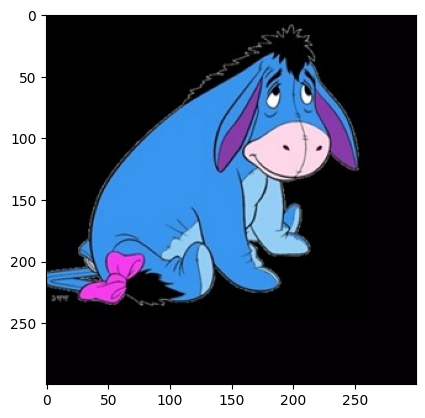

In [29]:
# Sample an image from the training set
seen_path     = random.choice(list(d_train.keys()))
pred_cap_seen = sample1Caption(seen_path, corpus, model, 1000)
gt_cap_seen   = d_train[seen_path][:5]
imshow(Image.open(seen_path))

print(f'[INFO] Five ground truth captions for this seen image:')
for cap in gt_cap_seen:
    print(f'\t{cap}')
print(f"[INFO] Caption sampled by fintuned CLIP for this seen image:\n\t{pred_cap_seen}")

[INFO] Five ground truth captions for this test image:
	Janet won't eat me because I'm land meat
	dress up cat name him steve only friend
	Look in the mirror hate myself
	friend wont play x-box with me try to hang myself
	Apathy Cow says Meh.
[INFO] Caption sampled by fintuned CLIP for this test image:
	SilEnce....sea of deadpan faces Le mooo-oooo-ve crowd roars


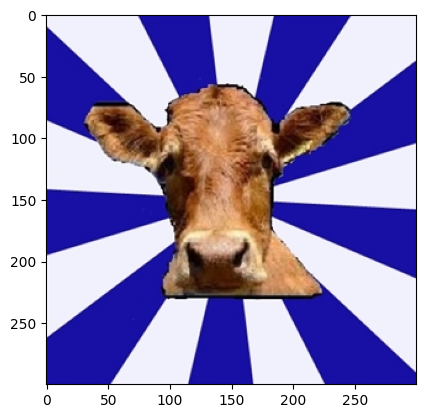

In [32]:
unseen_path     = random.choice(list(d_test.keys()))
pred_cap_unseen = sample1Caption(unseen_path, corpus, model, 1000)
imshow(Image.open(unseen_path))
gt_cap_unseen   = d_test[unseen_path][:5]

print(f'[INFO] Five ground truth captions for this test image:')
for cap in gt_cap_unseen:
    print(f'\t{cap}')
print(f"[INFO] Caption sampled by fintuned CLIP for this test image:\n\t{pred_cap_unseen}")